# Data Preparation for Linear Probing Analysis

## Overview
This notebook prepares multilingual datasets for probing the internal representations of the Tiny Aya model across 13 diverse languages. We create two complementary probing tasks:

1. **Language Identification Probing**: Using FLORES+ parallel corpus to test if the model can distinguish between languages
2. **Part-of-Speech Tagging Probing**: Using Universal Dependencies treebanks to test syntactic understanding

## Target Languages
- **High-resource**: English, Spanish, French, German  
- **Medium-resource**: Arabic, Hindi, Bengali*, Tamil, Turkish, Persian
- **Low-resource**: Swahili*, Amharic, Yoruba

*Note: Bengali uses UD Bengali-BRU/PUD treebanks (with GitHub fallback). Swahili uses MasakhaPOS dataset as alternative to UD.

## Datasets
- **FLORES+**: 500 samples per language for language identification
- **Universal Dependencies**: 100 sentences per language for POS tagging (primary source)
- **Alternative Sources**: 
  - Bengali: UD Bengali-BRU/PUD treebanks (with GitHub fallback if needed)
  - Swahili: MasakhaPOS dataset from Masakhane

The prepared data will be used to train linear probes on different layers of Tiny Aya to understand how linguistic knowledge emerges across the model's depth.



In [56]:
_DATASET_DIR = "../datasets"
_FIGURE_DIR = "../results/figures"


In [36]:
# Load HF_TOKEN from .env file
import os
from dotenv import load_dotenv

load_dotenv()

hf_token = os.getenv("HF_TOKEN")
if hf_token:
    print("HF_TOKEN successfully loaded from .env file.")
else:
    print("HF_TOKEN not found in .env file. Proceeding without authentication.")

HF_TOKEN successfully loaded from .env file.


In [37]:
# Language family and script mapping
# Note: Bengali and Swahili removed from POS task due to unavailability in UD
language_metadata = {
    'English': {'script': 'Latin', 'family': 'Indo-European', 'resource_level': 'High'},
    'Spanish': {'script': 'Latin', 'family': 'Indo-European', 'resource_level': 'High'},
    'French': {'script': 'Latin', 'family': 'Indo-European', 'resource_level': 'High'},
    'German': {'script': 'Latin', 'family': 'Indo-European', 'resource_level': 'High'},
    'Arabic': {'script': 'Arabic', 'family': 'Afro-Asiatic', 'resource_level': 'Medium'},
    'Hindi': {'script': 'Devanagari', 'family': 'Indo-European', 'resource_level': 'Medium'},
    'Bengali': {'script': 'Bengali', 'family': 'Indo-European', 'resource_level': 'Medium'},  # Available for language_id only
    'Tamil': {'script': 'Tamil', 'family': 'Dravidian', 'resource_level': 'Medium'},
    'Turkish': {'script': 'Latin', 'family': 'Turkic', 'resource_level': 'Medium'},
    'Persian': {'script': 'Arabic', 'family': 'Indo-European', 'resource_level': 'Medium'},
    'Swahili': {'script': 'Latin', 'family': 'Niger-Congo', 'resource_level': 'Low'},  # Available for language_id only
    'Amharic': {'script': 'Ethiopic', 'family': 'Afro-Asiatic', 'resource_level': 'Low'},
    'Yoruba': {'script': 'Latin', 'family': 'Niger-Congo', 'resource_level': 'Low'}
}

# Create short language code for label
lang_code_mapping = {
    'English': 'en', 'Spanish': 'es', 'French': 'fr', 'German': 'de',
    'Arabic': 'ar', 'Hindi': 'hi', 'Bengali': 'bn', 'Tamil': 'ta',
    'Turkish': 'tr', 'Persian': 'fa', 'Swahili': 'sw', 'Amharic': 'am', 'Yoruba': 'yo'
}

In [38]:
import json
from datasets import load_dataset
from collections import Counter
from tqdm import tqdm


# Configuration: Mapping your 13 languages to FLORES+ configs
# format: { 'human_readable_name': 'flores_plus_config_name' }
languages = {
    'English': 'eng_Latn',
    'Spanish': 'spa_Latn',
    'French': 'fra_Latn',
    'German': 'deu_Latn',
    'Arabic': 'arb_Arab',
    'Hindi': 'hin_Deva',
    'Bengali': 'ben_Beng',
    'Tamil': 'tam_Taml',
    'Turkish': 'tur_Latn',
    'Persian': 'pes_Arab',
    'Swahili': 'swh_Latn',
    'Amharic': 'amh_Ethi',
    'Yoruba': 'yor_Latn'
}

SAMPLES_PER_LANG = 500
output_data = []


for display_name, config in languages.items():
    print(f"Loading dataset for {display_name} ({config})...")
    
    try:
        dataset = load_dataset("openlanguagedata/flores_plus", config, split='dev', trust_remote_code=True)
        
        # Shuffle to ensure randomness for selected subset
        dataset = dataset.shuffle(seed=42)
        
        # Take exactly 500 samples
        subset = dataset.select(range(min(SAMPLES_PER_LANG, len(dataset))))
        
        for index, item in enumerate(tqdm(subset)):
            output_data.append({
                "id": f"{lang_code_mapping[display_name]}_{index + 1}",
                "text": item['text'],
                "language": display_name.lower(),
                "label": lang_code_mapping[display_name],
                "task": "language_id",
                "metadata": language_metadata.get(display_name, {'script': 'Unknown', 'family': 'Unknown', 'resource_level': 'Unknown'})
            })
            
    except Exception as e:
        print(f"❌ Error loading {display_name}: {e}")



print(f"\n Done! Prepared {len(output_data)} examples.")
print(f"Stats: {dict(Counter(d['label'] for d in output_data))}")

Loading dataset for English (eng_Latn)...


100%|██████████| 500/500 [00:00<00:00, 15665.12it/s]


Loading dataset for Spanish (spa_Latn)...


100%|██████████| 500/500 [00:00<00:00, 16345.82it/s]


Loading dataset for French (fra_Latn)...


...

Loading dataset for Amharic (amh_Ethi)...


100%|██████████| 500/500 [00:00<00:00, 15755.50it/s]


Loading dataset for Yoruba (yor_Latn)...


100%|██████████| 500/500 [00:00<00:00, 15353.07it/s]


 Done! Prepared 6500 examples.
Stats: {'en': 500, 'es': 500, 'fr': 500, 'de': 500, 'ar': 500, 'hi': 500, 'bn': 500, 'ta': 500, 'tr': 500, 'fa': 500, 'sw': 500, 'am': 500, 'yo': 500}


In [39]:
output_data[0]

{'id': 'en_1',
 'text': 'Nevertheless, all French-speaking Belgians and Swiss would have learned standard French in school, so they would be able to understand you even if you used the standard French numbering system.',
 'language': 'english',
 'label': 'en',
 'task': 'language_id',
 'metadata': {'script': 'Latin',
  'family': 'Indo-European',
  'resource_level': 'High'}}

In [40]:
# Save to JSON
import os
os.makedirs(_DATASET_DIR, exist_ok=True)

with open(os.path.join(_DATASET_DIR, 'language_id_probing_data.json'), 'w', encoding='utf-8') as f:
    json.dump(output_data, f, ensure_ascii=False, indent=2)

In [41]:
# CORRECT Universal POS (UPOS) tags mapping from HuggingFace UD dataset
# This is the EXACT order used in the dataset's ClassLabel feature
UPOS_TAGS = [
    "NOUN",    # 0
    "PUNCT",   # 1
    "ADP",     # 2
    "NUM",     # 3
    "SYM",     # 4
    "SCONJ",   # 5
    "ADJ",     # 6
    "PART",    # 7
    "DET",     # 8
    "CCONJ",   # 9
    "PROPN",   # 10
    "PRON",    # 11
    "X",       # 12
    "_",       # 13 (unknown/missing)
    "ADV",     # 14
    "INTJ",    # 15
    "VERB",    # 16
    "AUX",     # 17
]

print("✅ UPOS tag mapping verified against HuggingFace UD dataset source code")

# Test the mapping with a sample
try:
    test_dataset = load_dataset("universal_dependencies", "en_gum", split='train[:1]', trust_remote_code=True)
    sample = test_dataset[0]
    print(f"\nVerification with English sample:")
    print(f"Tokens: {sample['tokens'][:5]}")
    print(f"UPOS IDs: {sample['upos'][:5]}")
    print(f"Mapped UPOS: {[UPOS_TAGS[i] if i < len(UPOS_TAGS) else 'UNK' for i in sample['upos'][:5]]}")
except Exception as e:
    print(f"⚠️  Could not verify mapping: {e}")


✅ UPOS tag mapping verified against HuggingFace UD dataset source code

Verification with English sample:
Tokens: ['Aesthetic', 'Appreciation', 'and', 'Spanish', 'Art']
UPOS IDs: [6, 0, 9, 6, 0]
Mapped UPOS: ['ADJ', 'NOUN', 'CCONJ', 'ADJ', 'NOUN']


In [42]:
import json
from datasets import load_dataset
from collections import Counter
from tqdm import tqdm 

# Primary UD Treebank Configs
ud_configs = {
    'English': ('en_gum', 'train'),
    'Spanish': ('es_ancora', 'train'),
    'French': ('fr_gsd', 'train'),
    'German': ('de_gsd', 'train'),
    'Arabic': ('ar_padt', 'train'),
    'Hindi': ('hi_hdtb', 'train'),
    'Tamil': ('ta_ttb', 'train'),
    'Turkish': ('tr_boun', 'train'),
    'Persian': ('fa_seraji', 'train'),
    'Amharic': ('am_att', 'test'),  # Only test split available
    'Yoruba': ('yo_ytb', 'test')    # Only test split available
}


SAMPLES_PER_LANG = 100
pos_data = []

print("Starting POS Dataset Preparation...")

for display_name, (config, split) in ud_configs.items():
    print(f"Loading UD {display_name} ({config})...")
    try:
        # Load the dataset with the appropriate split
        dataset = load_dataset("universal_dependencies", config, split=split, trust_remote_code=True)
        dataset = dataset.shuffle(seed=42)
        
        subset = dataset.select(range(min(SAMPLES_PER_LANG, len(dataset))))
        
        for index, item in enumerate(tqdm(subset)):
            # item['tokens'] is a list of words
            # item['upos'] is a list of integer IDs for POS tags
            # Map POS IDs to actual POS tag strings
            pos_labels = [UPOS_TAGS[pos_id] if 0 <= pos_id < len(UPOS_TAGS) else "X" for pos_id in item['upos']]
            
            
            pos_data.append({
                "id":  f"{lang_code_mapping[display_name]}_{index + 1}", # Sequential ID
                "language": display_name.lower(),
                "label": lang_code_mapping[display_name],
                "text": item['text'],
                "tokens": item['tokens'],
                "pos_tags": pos_labels,
                "task": "pos_tagging",
                "metadata": language_metadata.get(display_name, {'script': 'Unknown', 'family': 'Unknown', 'resource_level': 'Unknown'})
            })
            
    except Exception as e:
        print(f"❌ Error loading {display_name}: {e}")


print(f"\nDone! Prepared {len(pos_data)} sentences for POS probing.")

Starting POS Dataset Preparation...
Loading UD English (en_gum)...


100%|██████████| 100/100 [00:00<00:00, 6261.00it/s]


Loading UD Spanish (es_ancora)...


100%|██████████| 100/100 [00:00<00:00, 759.11it/s]


Loading UD French (fr_gsd)...


...

Loading UD Amharic (am_att)...


100%|██████████| 100/100 [00:00<00:00, 5853.47it/s]


Loading UD Yoruba (yo_ytb)...


100%|██████████| 100/100 [00:00<00:00, 4762.84it/s]


Done! Prepared 1100 sentences for POS probing.


In [43]:
# Save to JSON
import os
os.makedirs(_DATASET_DIR, exist_ok=True)

with open(os.path.join(_DATASET_DIR, 'pos_probing_data.json'), 'w', encoding='utf-8') as f:
    json.dump(pos_data, f, ensure_ascii=False, indent=2)

##  Bar Charts - Sample Counts per Language for Both Tasks

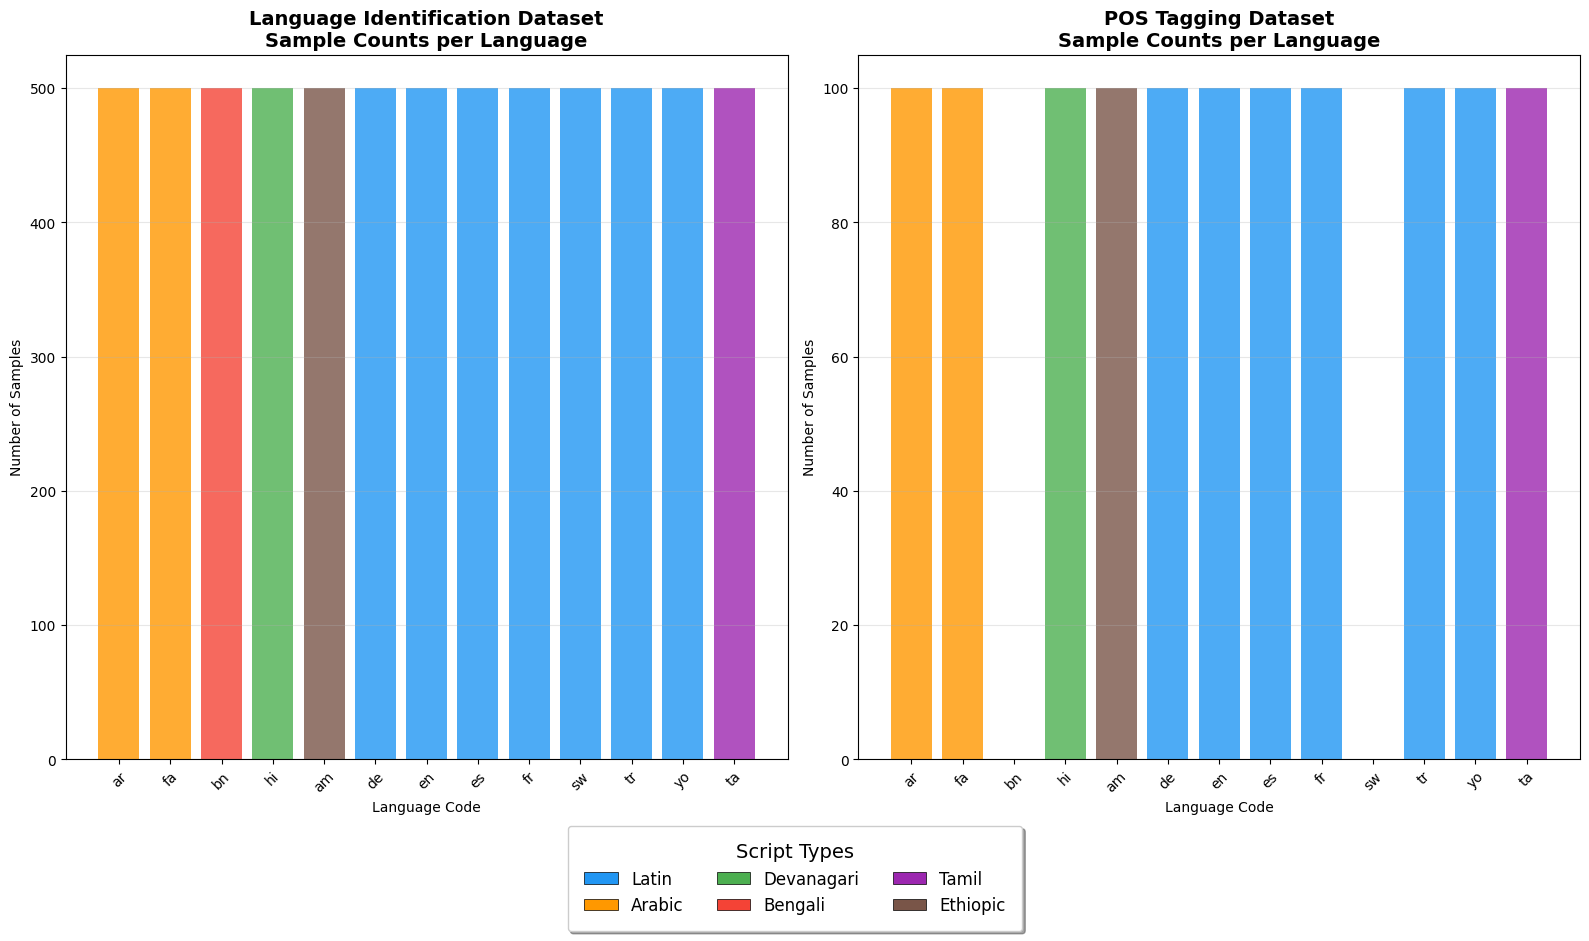

Figures saved to: ../results/figures
Dataset Summary:
Language ID: 6500 total samples across 13 languages
POS Tagging: 1100 total samples across 11 languages
Languages with both tasks: 11


In [59]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import Counter
import numpy as np

# Load both datasets
with open('../datasets/language_id_probing_data.json', 'r', encoding='utf-8') as f:
    lang_id_data = json.load(f)

with open('../datasets/pos_probing_data.json', 'r', encoding='utf-8') as f:
    pos_data = json.load(f)

# Create reverse mapping from language code to script (needed for sorting)
lang_to_script = {}
for lang_name, metadata in language_metadata.items():
    lang_code = lang_code_mapping[lang_name]
    lang_to_script[lang_code] = metadata['script']

# Count samples per language for both tasks
lang_id_counts = Counter(item['label'] for item in lang_id_data)
pos_counts = Counter(item['label'] for item in pos_data)

# Create DataFrame for visualization
all_languages = set(lang_id_counts.keys()) | set(pos_counts.keys())
comparison_data = []

for lang in all_languages:
    comparison_data.append({
        'Language': lang,
        'Language ID': lang_id_counts.get(lang, 0),
        'POS Tagging': pos_counts.get(lang, 0),
        'Script': lang_to_script.get(lang, 'Unknown')
    })

df_comparison = pd.DataFrame(comparison_data)

# Group languages with the same script together
df_comparison = df_comparison.sort_values(['Script', 'Language'])

# Define color mapping for script styles
script_color_map = {
    "Latin": "#2196F3",
    "Arabic": "#FF9800", 
    "Devanagari": "#4CAF50",
    "Bengali": "#F44336",
    "Tamil": "#9C27B0",
    "Ethiopic": "#795548",
}

# Get colors for each language based on script
def get_colors_for_languages(languages):
    colors = []
    for lang in languages:
        script = lang_to_script.get(lang, 'Unknown')
        color = script_color_map.get(script, '#757575')  # Gray for unknown
        colors.append(color)
    return colors

# Create the visualization with extra space for legend
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 9))

# Get colors for the languages
lang_colors = get_colors_for_languages(df_comparison['Language'])

# Language ID samples
ax1.bar(df_comparison['Language'], df_comparison['Language ID'], 
        color=lang_colors, alpha=0.8)
ax1.set_title('Language Identification Dataset\nSample Counts per Language', fontsize=14, fontweight='bold')
ax1.set_xlabel('Language Code')
ax1.set_ylabel('Number of Samples')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# POS Tagging samples
ax2.bar(df_comparison['Language'], df_comparison['POS Tagging'], 
        color=lang_colors, alpha=0.8)
ax2.set_title('POS Tagging Dataset\nSample Counts per Language', fontsize=14, fontweight='bold')
ax2.set_xlabel('Language Code')
ax2.set_ylabel('Number of Samples')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

# Add legend for script styles below the charts
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=script, edgecolor='black', linewidth=0.5) 
                  for script, color in script_color_map.items()]

# Position legend below the charts with better visibility
fig.legend(handles=legend_elements, 
          loc='lower center', 
          bbox_to_anchor=(0.5, -0.05),
          ncol=3,  # 3 columns for better layout
          fontsize=12, 
          title='Script Types',
          title_fontsize=14,
          frameon=True,
          fancybox=True,
          shadow=True,
          borderpad=1)

os.makedirs(_FIGURE_DIR, exist_ok=True)

# Adjust layout to make room for legend below
plt.tight_layout()
plt.subplots_adjust(bottom=0.15) 

# Save the figure
plt.savefig(os.path.join(_FIGURE_DIR, 'dataset_comparison.png'), 
            dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

print(f"Figures saved to: {_FIGURE_DIR}")

# Print summary statistics
print("Dataset Summary:")
print(f"Language ID: {len(lang_id_data)} total samples across {len(lang_id_counts)} languages")
print(f"POS Tagging: {len(pos_data)} total samples across {len(pos_counts)} languages")
print(f"Languages with both tasks: {len(set(lang_id_counts.keys()) & set(pos_counts.keys()))}")

## Script Diversity Visualization

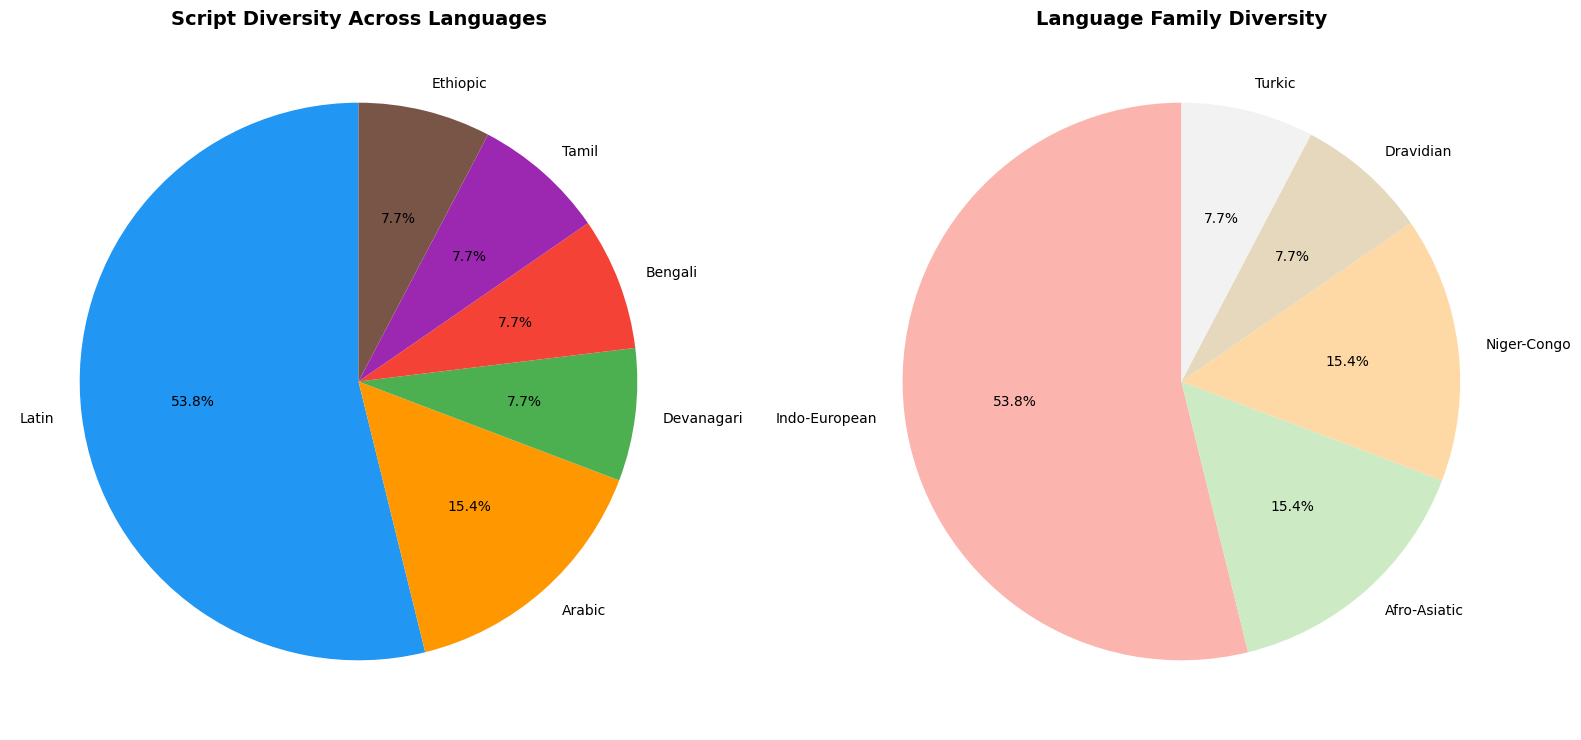

Script Distribution:
  Latin: 7 languages (en, es, fr, de, tr, sw, yo)
  Arabic: 2 languages (ar, fa)
  Devanagari: 1 languages (hi)
  Bengali: 1 languages (bn)
  Tamil: 1 languages (ta)
  Ethiopic: 1 languages (am)

Language Family Distribution:
  Indo-European: 7 languages (en, es, fr, de, hi, bn, fa)
  Afro-Asiatic: 2 languages (ar, am)
  Niger-Congo: 2 languages (sw, yo)
  Dravidian: 1 languages (ta)
  Turkic: 1 languages (tr)


In [ ]:
# Extract script information from metadata
script_data = []
for item in lang_id_data:
    script_data.append({
        'language': item['label'],
        'script': item['metadata']['script'],
        'family': item['metadata']['family'],
        'resource_level': item['metadata']['resource_level']
    })

script_df = pd.DataFrame(script_data).drop_duplicates()

# Count languages per script
script_counts = script_df['script'].value_counts()
family_counts = script_df['family'].value_counts()

# Define custom colors for scripts (using the specified color mapping)
script_color_map_pie = {
    "Latin": "#2196F3",      # Blue
    "Arabic": "#FF9800",     # Orange
    "Devanagari": "#4CAF50", # Green
    "Bengali": "#F44336",    # Red
    "Tamil": "#9C27B0",      # Purple
    "Ethiopic": "#795548"    # Brown
}

# Create colors list for pie chart based on script order
colors_script = [script_color_map_pie.get(script, '#757575') for script in script_counts.index]

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Script diversity pie chart with custom colors
wedges, texts, autotexts = ax1.pie(script_counts.values, labels=script_counts.index, 
                                   autopct='%1.1f%%', colors=colors_script, startangle=90)
ax1.set_title('Script Diversity Across Languages', fontsize=14, fontweight='bold')

# Language family diversity (using default colormap for families)
colors_family = plt.cm.Pastel1(np.linspace(0, 1, len(family_counts)))
wedges2, texts2, autotexts2 = ax2.pie(family_counts.values, labels=family_counts.index, 
                                       autopct='%1.1f%%', colors=colors_family, startangle=90)
ax2.set_title('Language Family Diversity', fontsize=14, fontweight='bold')

plt.tight_layout()

# Save the figure
plt.savefig(os.path.join(_FIGURE_DIR, 'script_family_diversity.png'), 
            dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

# Print detailed breakdown
print("Script Distribution:")
for script, count in script_counts.items():
    languages = script_df[script_df['script'] == script]['language'].tolist()
    print(f"  {script}: {count} languages ({', '.join(languages)})")

print("\nLanguage Family Distribution:")
for family, count in family_counts.items():
    languages = script_df[script_df['family'] == family]['language'].tolist()
    print(f"  {family}: {count} languages ({', '.join(languages)})")

## Heatmap of POS Tag Frequencies Across Languages

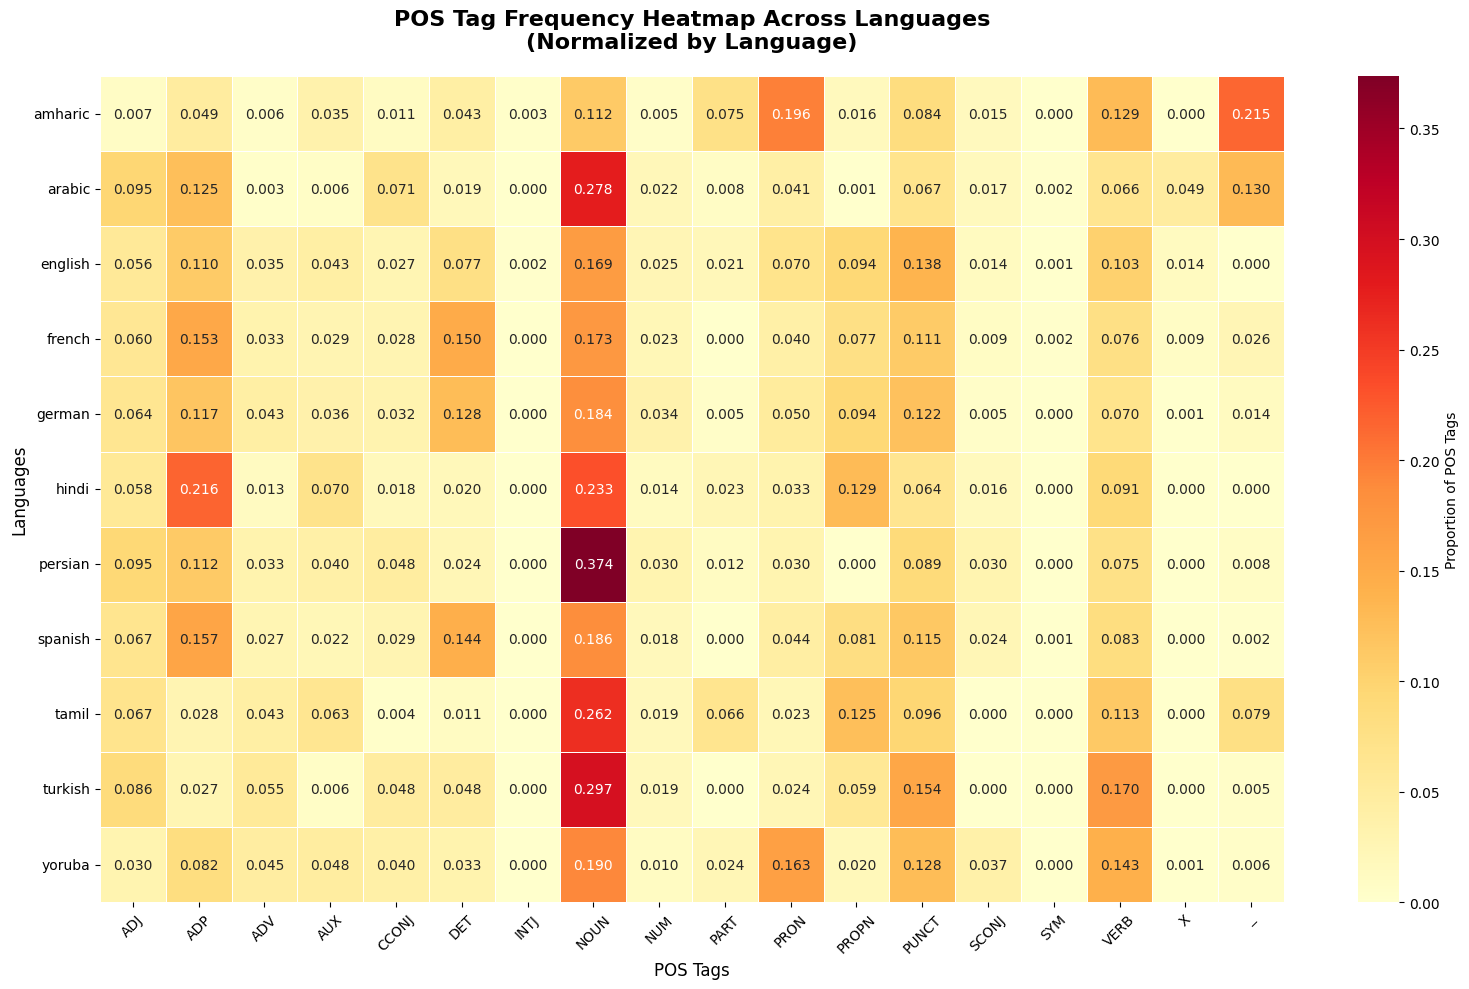

🏷️ POS Tag Analysis:

AMHARIC:
  Most common: _(0.215), PRON(0.196), VERB(0.129)
  Least common: ADV(0.006), NUM(0.005), INTJ(0.003)

ARABIC:
  Most common: NOUN(0.278), _(0.130), ADP(0.125)
  Least common: ADV(0.003), SYM(0.002), PROPN(0.001)

ENGLISH:
  Most common: NOUN(0.169), PUNCT(0.138), ADP(0.110)
  Least common: X(0.014), INTJ(0.002), SYM(0.001)

FRENCH:
  Most common: NOUN(0.173), ADP(0.153), DET(0.150)
  Least common: X(0.009), SYM(0.002), INTJ(0.000)

GERMAN:
  Most common: NOUN(0.184), DET(0.128), PUNCT(0.122)
  Least common: SCONJ(0.005), PART(0.005), X(0.001)

HINDI:
  Most common: NOUN(0.233), ADP(0.216), PROPN(0.129)
  Least common: NUM(0.014), ADV(0.013), X(0.000)

PERSIAN:
  Most common: NOUN(0.374), ADP(0.112), ADJ(0.095)
  Least common: PART(0.012), _(0.008), X(0.000)

SPANISH:
  Most common: NOUN(0.186), ADP(0.157), DET(0.144)
  Least common: SYM(0.001), INTJ(0.000), PART(0.000)

TAMIL:
  Most common: NOUN(0.262), PROPN(0.125), VERB(0.113)
  Least common: NUM(0.01

In [ ]:
# Create POS tag frequency matrix
pos_tag_data = []
for item in pos_data:
    for tag in item['pos_tags']:
        pos_tag_data.append({
            'language': item['language'],
            'pos_tag': tag
        })

pos_tag_df = pd.DataFrame(pos_tag_data)

# Create frequency matrix
pos_freq_matrix = pos_tag_df.groupby(['language', 'pos_tag']).size().unstack(fill_value=0)

# Normalize by language (show proportions)
pos_freq_normalized = pos_freq_matrix.div(pos_freq_matrix.sum(axis=1), axis=0)

# Create heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(pos_freq_normalized, 
            annot=True, 
            fmt='.3f', 
            cmap='YlOrRd', 
            cbar_kws={'label': 'Proportion of POS Tags'},
            linewidths=0.5)

plt.title('POS Tag Frequency Heatmap Across Languages\n(Normalized by Language)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('POS Tags', fontsize=12)
plt.ylabel('Languages', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

# Save the figure
plt.savefig(os.path.join(_FIGURE_DIR, 'pos_heatmap.png'), 
            dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

# Print most/least common tags per language
print("POS Tag Analysis:")
for lang in pos_freq_normalized.index:
    lang_tags = pos_freq_normalized.loc[lang].sort_values(ascending=False)
    most_common = lang_tags.head(3)
    least_common = lang_tags[lang_tags > 0].tail(3)
    
    print(f"\n{lang.upper()}:")
    print(f"  Most common: {', '.join([f'{tag}({val:.3f})' for tag, val in most_common.items()])}")
    print(f"  Least common: {', '.join([f'{tag}({val:.3f})' for tag, val in least_common.items()])}")

## 📊 Cross-Linguistic POS Tag Diversity Analysis

This section examines the morphosyntactic complexity and diversity of Part-of-Speech (POS) tag distributions across languages in our dataset. Understanding tag diversity is crucial for linear probing experiments as it reveals how grammatical complexity varies between languages and may influence model performance.

### Diversity Metrics

We calculate four complementary metrics to capture different aspects of POS tag diversity:

- **Unique Tags Count**: The total number of distinct POS tags used in each language
- **Shannon Diversity Index**: Measures both richness (number of categories) and evenness (distribution balance) of POS tags, with higher values indicating more diverse tag usage
- **Simpson Diversity Index**: Probability-based measure where values closer to 1 indicate higher diversity
- **Tag Dominance**: The proportion of the most frequent POS tag, where higher values suggest grammatical uniformity

### Key Insights

This analysis helps identify:
- Languages with rich morphological systems (high diversity scores)
- Languages with simpler or more uniform grammatical structures (high dominance scores)
- Potential challenges for cross-lingual transfer learning based on grammatical complexity differences
- Whether certain languages might serve as better sources or targets for probing experiments


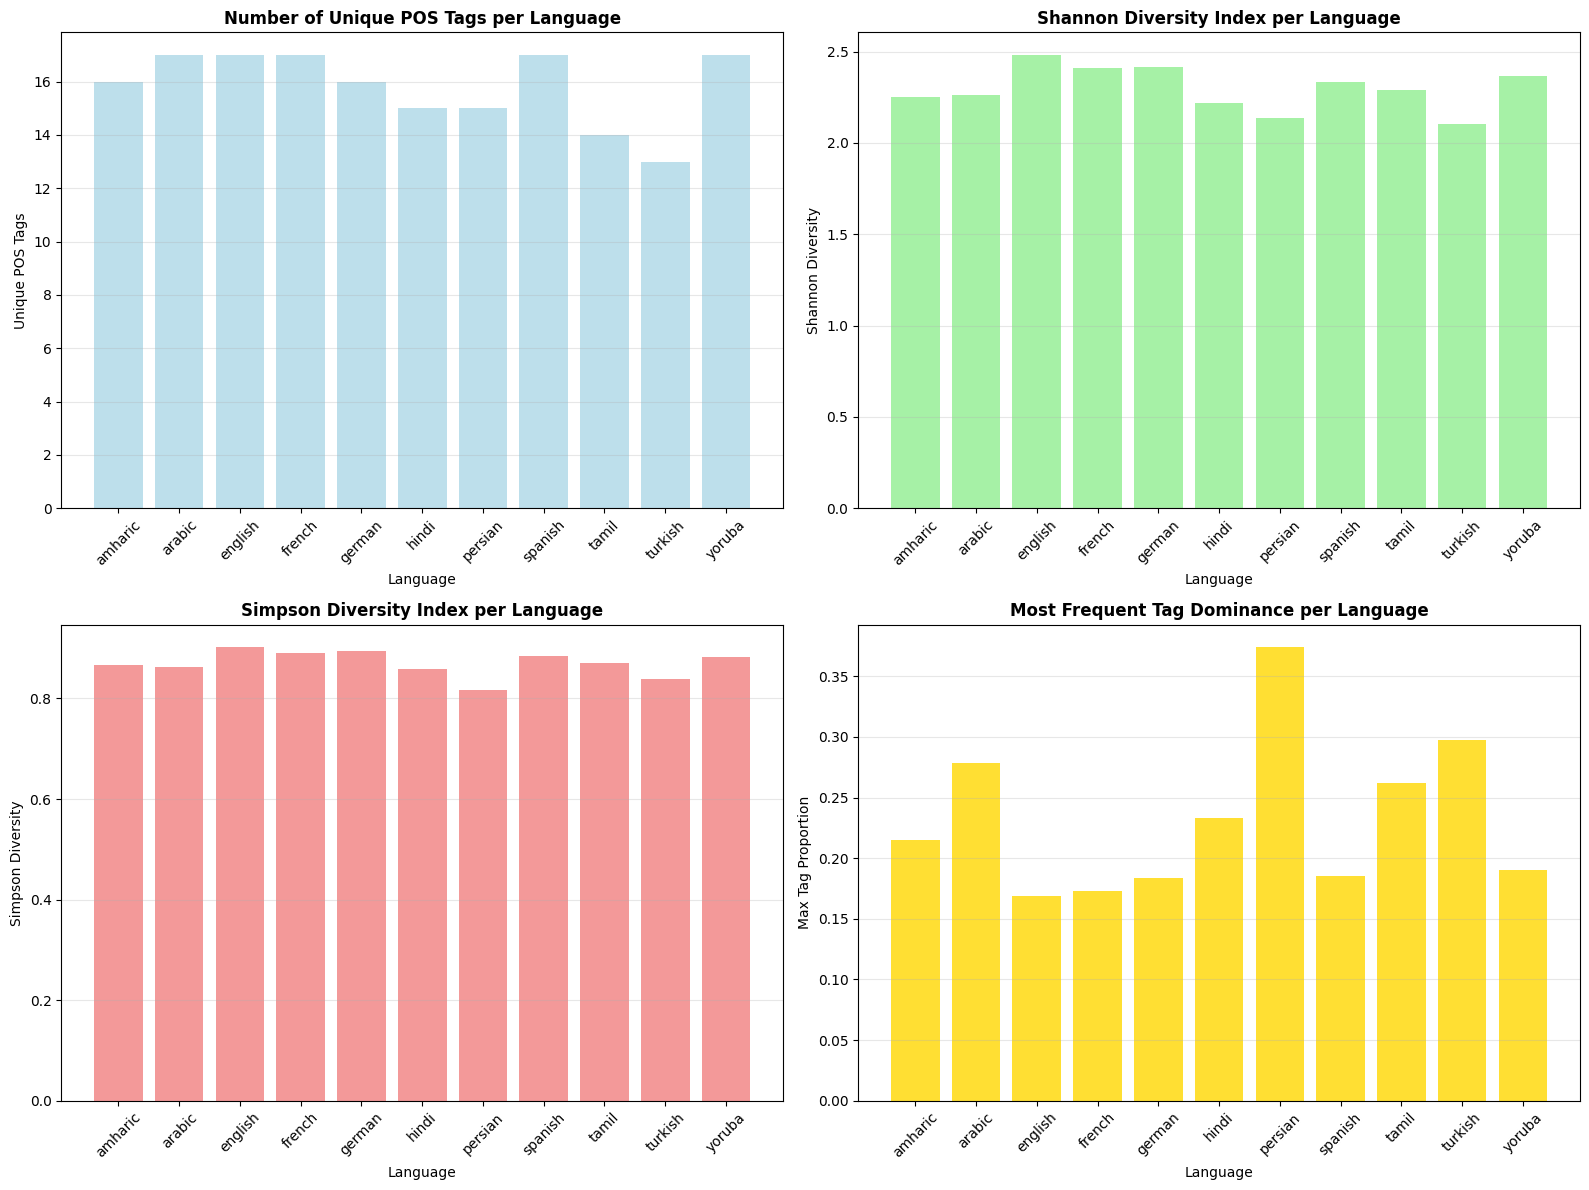

🎯 Tag Diversity Rankings:

Most Diverse Languages (Shannon Index):
  english: 2.481
  german: 2.417
  french: 2.409
  yoruba: 2.364
  spanish: 2.332

Least Diverse Languages (Highest Dominance):
  persian: 0.374
  turkish: 0.297
  arabic: 0.278
  tamil: 0.262
  hindi: 0.233


In [ ]:
# Calculate tag diversity metrics for each language
diversity_metrics = []

for lang in pos_freq_matrix.index:
    lang_tags = pos_freq_matrix.loc[lang]
    total_tags = lang_tags.sum()
    unique_tags = (lang_tags > 0).sum()
    
    # Shannon diversity index
    proportions = lang_tags[lang_tags > 0] / total_tags
    shannon_diversity = -sum(p * np.log(p) for p in proportions)
    
    # Simpson diversity index
    simpson_diversity = 1 - sum(p**2 for p in proportions)
    
    # Most frequent tag dominance
    max_proportion = proportions.max()
    
    diversity_metrics.append({
        'language': lang,
        'unique_tags': unique_tags,
        'total_tokens': total_tags,
        'shannon_diversity': shannon_diversity,
        'simpson_diversity': simpson_diversity,
        'max_tag_dominance': max_proportion
    })

diversity_df = pd.DataFrame(diversity_metrics)

# Create visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Unique tags per language
ax1.bar(diversity_df['language'], diversity_df['unique_tags'], 
        color='lightblue', alpha=0.8)
ax1.set_title('Number of Unique POS Tags per Language', fontweight='bold')
ax1.set_xlabel('Language')
ax1.set_ylabel('Unique POS Tags')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Shannon diversity
ax2.bar(diversity_df['language'], diversity_df['shannon_diversity'], 
        color='lightgreen', alpha=0.8)
ax2.set_title('Shannon Diversity Index per Language', fontweight='bold')
ax2.set_xlabel('Language')
ax2.set_ylabel('Shannon Diversity')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

# Simpson diversity
ax3.bar(diversity_df['language'], diversity_df['simpson_diversity'], 
        color='lightcoral', alpha=0.8)
ax3.set_title('Simpson Diversity Index per Language', fontweight='bold')
ax3.set_xlabel('Language')
ax3.set_ylabel('Simpson Diversity')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(axis='y', alpha=0.3)

# Tag dominance (inverse of diversity)
ax4.bar(diversity_df['language'], diversity_df['max_tag_dominance'], 
        color='gold', alpha=0.8)
ax4.set_title('Most Frequent Tag Dominance per Language', fontweight='bold')
ax4.set_xlabel('Language')
ax4.set_ylabel('Max Tag Proportion')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()

# Save the figure
plt.savefig(os.path.join(_FIGURE_DIR, 'pos_tag_diversity_comparison.png'), 
            dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

# Print diversity rankings
print("🎯 Tag Diversity Rankings:")
print("\nMost Diverse Languages (Shannon Index):")
top_diverse = diversity_df.nlargest(5, 'shannon_diversity')[['language', 'shannon_diversity']]
for _, row in top_diverse.iterrows():
    print(f"  {row['language']}: {row['shannon_diversity']:.3f}")

print("\nLeast Diverse Languages (Highest Dominance):")
least_diverse = diversity_df.nlargest(5, 'max_tag_dominance')[['language', 'max_tag_dominance']]
for _, row in least_diverse.iterrows():
    print(f"  {row['language']}: {row['max_tag_dominance']:.3f}")